# Analyse Exploratoire Maintenance Prédictive
## Dataset : 10 000 équipements industriels
---
**Objectif** : Comprendre les données avant de construire un modèle ML de détection de pannes.

**Plan d'analyse :**
1. Chargement & aperçu général
2. Qualité des données (manquants + aberrants)
3. Distribution des variables numériques
4. Variables catégorielles
5. Analyse de la variable cible `panne`
6. Corrélations & relations entre variables
7. Profil des machines en panne vs sans panne
8. Synthèse & recommandations pré-modélisation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0',
            '#00BCD4', '#795548', '#607D8B', '#E91E63', '#3F51B5']
C_OK     = '#2196F3'   # Bleu  = pas de panne
C_PANNE  = '#F44336'   # Rouge = panne

print("✅ Bibliothèques chargées")


✅ Bibliothèques chargées


## 1. Chargement & aperçu général

In [ ]:
df = pd.read_csv('dataset_maintenance_predictive.csv')

print(f" Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"💾Mémoire    : {df.memory_usage(deep=True).sum() / 1e6:.2f} Mo\n")
df.head(8)


 Dimensions : 10,000 lignes × 28 colonnes
💾 Mémoire    : 7.30 Mo



,id,modele_machine,annee_fabrication,fiabilite_modele,age_machine_ans,phase_vie,indice_usure,heures_par_jour,temps_total_fonctionnement_h,mode_fonctionnement,...,intervalle_entre_maintenances_j,nombre_total_pannes,frequence_pannes_par_an,duree_moyenne_panne_h,nombre_interventions_techniques,nombre_pannes_repetees,type_panne_recurrente,intervalle_entre_pannes_j,cause_identifiee,panne
0,1,ROBOT-M3,1996,Faible,27,Ancienne,92.03,13.1,128778,Intermittent,...,112.0,21,0.78,NaN,23,20,Électrique,225,NaN,1
1,2,PUMP-V7,2000,Moyenne,23,Ancienne,75.59,9.1,76567,Continu,...,64.0,26,1.13,2.29,29,24,Mécanique,160,Oui,0
2,3,PRESS-X5,2021,Moyenne,2,Nouvelle,11.28,11.3,8405,Continu,...,66.0,2,1.00,12.74,5,1,Mécanique,141,Non,0
3,4,COMP-T2,1995,Moyenne,28,Ancienne,97.09,17.0,173505,Continu,...,111.0,18,0.64,6.33,21,16,Thermique,77,Oui,1
4,5,MOTOR-K1,2009,Moyenne,14,Normale,50.01,8.7,44109,Continu,...,NaN,9,0.64,5.01,11,8,Hydraulique,183,Oui,0
5,6,LATHE-9,2009,Elevée,14,Normale,49.82,13.0,66227,Intermittent,...,57.0,8,0.57,0.50,10,6,Thermique,158,Oui,0
6,7,ROBOT-M3,2008,Moyenne,15,Normale,52.77,15.5,84629,Continu,...,59.0,11,0.73,5.17,11,11,Électrique,158,Oui,0
7,8,DRILL-Z6,2001,Elevée,22,Ancienne,77.46,9.0,72545,Continu,...,84.0,18,0.82,0.50,20,18,Hydraulique,139,Oui,0


In [3]:
# Types et taux de remplissage
info = pd.DataFrame({
    'Type'          : df.dtypes,
    'Non-nuls'      : df.notnull().sum(),
    'Nulls'         : df.isnull().sum(),
    'Taux rempli %' : (df.notnull().sum() / len(df) * 100).round(1),
    'Exemple'       : [df[c].dropna().iloc[0] if df[c].notnull().any() else 'N/A' for c in df.columns]
})
info.style.background_gradient(subset=['Taux rempli %'], cmap='RdYlGn')


,Type,Non-nuls,Nulls,Taux rempli %,Exemple
id,int64,10000,0,100.000000,1
modele_machine,object,10000,0,100.000000,ROBOT-M3
annee_fabrication,int64,10000,0,100.000000,1996
fiabilite_modele,object,9500,500,95.000000,Faible
age_machine_ans,int64,10000,0,100.000000,27
phase_vie,object,9500,500,95.000000,Ancienne
indice_usure,float64,9500,500,95.000000,92.030000
heures_par_jour,float64,9500,500,95.000000,13.100000
temps_total_fonctionnement_h,int64,10000,0,100.000000,128778
mode_fonctionnement,object,10000,0,100.000000,Intermittent


In [4]:
df.describe(include='all').T.style.format(precision=2).background_gradient(cmap='Blues', subset=['mean','std'])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.00,nan,nan,nan,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
modele_machine,10000,10,CNC-2000,1020,nan,nan,nan,nan,nan,nan,nan
annee_fabrication,10000.00,nan,nan,nan,2020.32,378.73,0.00,2001.00,2008.50,2016.00,9999.00
fiabilite_modele,9500,3,Elevée,4288,nan,nan,nan,nan,nan,nan,nan
age_machine_ans,10000.00,nan,nan,nan,15.01,11.13,0.00,7.00,14.50,22.00,123.00
phase_vie,9500,3,Ancienne,4423,nan,nan,nan,nan,nan,nan,nan
indice_usure,9500.00,nan,nan,nan,53.76,59.98,-20.00,26.18,50.61,75.71,999.00
heures_par_jour,9500.00,nan,nan,nan,12.28,5.42,-5.00,10.00,12.10,14.10,100.00
temps_total_fonctionnement_h,10000.00,nan,nan,nan,67239.97,60028.03,0.00,30802.25,60026.00,92541.50,1021939.00
mode_fonctionnement,10000,2,Continu,5960,nan,nan,nan,nan,nan,nan,nan


## 2. Qualité des données
### 2.1 Valeurs manquantes

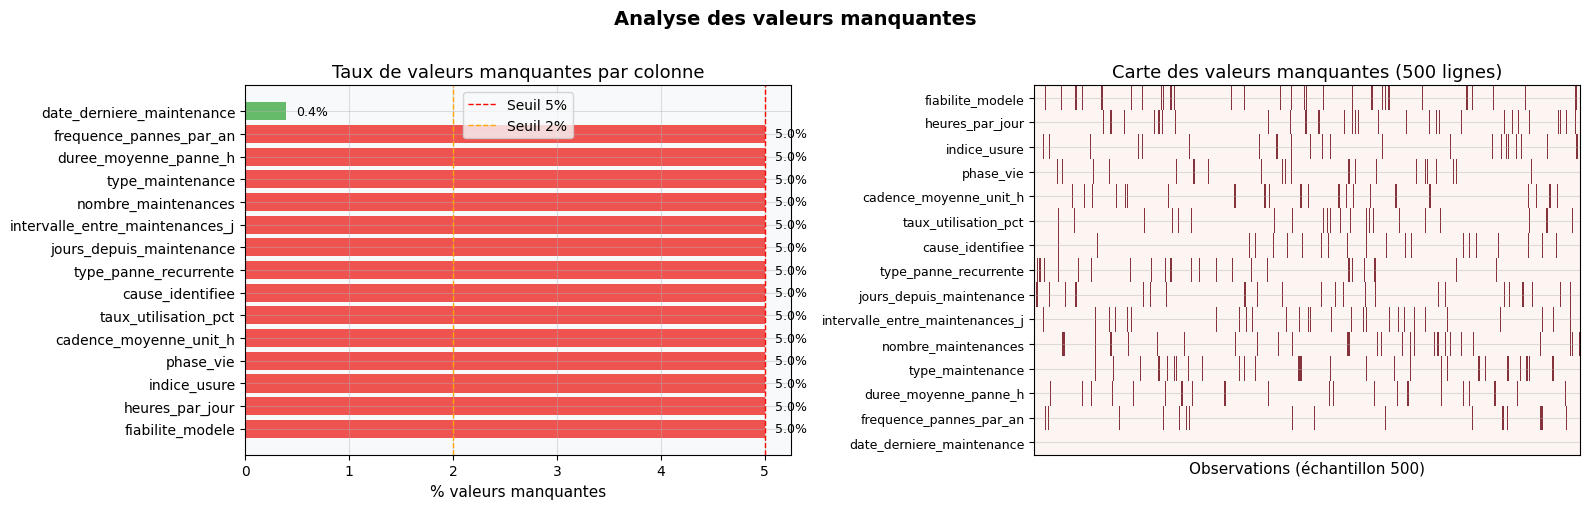


📊 Total NaN : 7,039 | Taux global : 2.51%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barres
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
colors  = ['#EF5350' if v/len(df)>0.04 else '#FFA726' if v/len(df)>0.02 else '#66BB6A'
           for v in missing.values]
axes[0].barh(missing.index, missing.values / len(df) * 100, color=colors)
axes[0].set_xlabel("% valeurs manquantes")
axes[0].set_title("Taux de valeurs manquantes par colonne")
for i, v in enumerate(missing.values):
    axes[0].text(v/len(df)*100 + 0.1, i, f"{v/len(df)*100:.1f}%", va='center', fontsize=9)
axes[0].axvline(5, color='red',    ls='--', lw=1, label='Seuil 5%')
axes[0].axvline(2, color='orange', ls='--', lw=1, label='Seuil 2%')
axes[0].legend()

# Carte des nulls (heatmap légère sur 500 lignes)
sample  = df.sample(500, random_state=42)[missing.index]
null_map = sample.isnull().astype(int)
axes[1].imshow(null_map.T, aspect='auto', cmap='Reds', interpolation='none', alpha=0.8)
axes[1].set_yticks(range(len(missing.index)))
axes[1].set_yticklabels(missing.index, fontsize=9)
axes[1].set_xlabel("Observations (échantillon 500)")
axes[1].set_title("Carte des valeurs manquantes (500 lignes)")
axes[1].set_xticks([])

plt.suptitle("Analyse des valeurs manquantes", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n📊 Total NaN : {df.isnull().sum().sum():,} | "
      f"Taux global : {df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100:.2f}%")


### 2.2 Données aberrantes

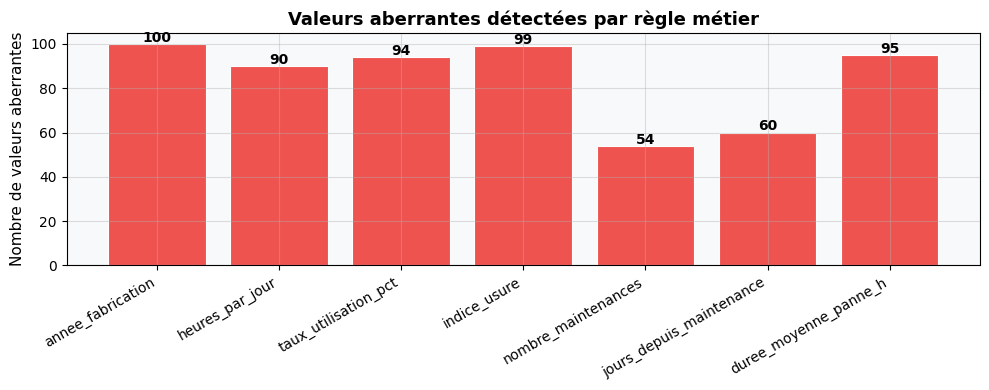


⚠️  Total aberrants détectés (doublons possibles) : 592
📌 Soit ~5.9% du dataset


In [6]:
# Détection règles métier
aberrants = {
    'annee_fabrication'        : ((df['annee_fabrication'] < 1990) | (df['annee_fabrication'] > 2023)).sum(),
    'heures_par_jour'          : ((df['heures_par_jour'] < 1) | (df['heures_par_jour'] > 24)).sum(),
    'taux_utilisation_pct'     : (df['taux_utilisation_pct'] > 100).sum(),
    'indice_usure'             : ((df['indice_usure'] < 0) | (df['indice_usure'] > 100)).sum(),
    'nombre_maintenances'      : (df['nombre_maintenances'] < 0).sum(),
    'jours_depuis_maintenance' : (df['jours_depuis_maintenance'] > 1000).sum(),
    'duree_moyenne_panne_h'    : ((df['duree_moyenne_panne_h'] < 0) | (df['duree_moyenne_panne_h'] > 200)).sum(),
}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(list(aberrants.keys()), list(aberrants.values()),
              color='#EF5350', edgecolor='white', linewidth=0.8)
ax.set_xticklabels(list(aberrants.keys()), rotation=30, ha='right')
ax.set_ylabel("Nombre de valeurs aberrantes")
ax.set_title("Valeurs aberrantes détectées par règle métier", fontweight='bold')
for bar, val in zip(bars, aberrants.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

total_ab = sum(aberrants.values())
print(f"\n⚠️  Total aberrants détectés (doublons possibles) : {total_ab}")
print(f"📌 Soit ~{total_ab/len(df)*100:.1f}% du dataset")


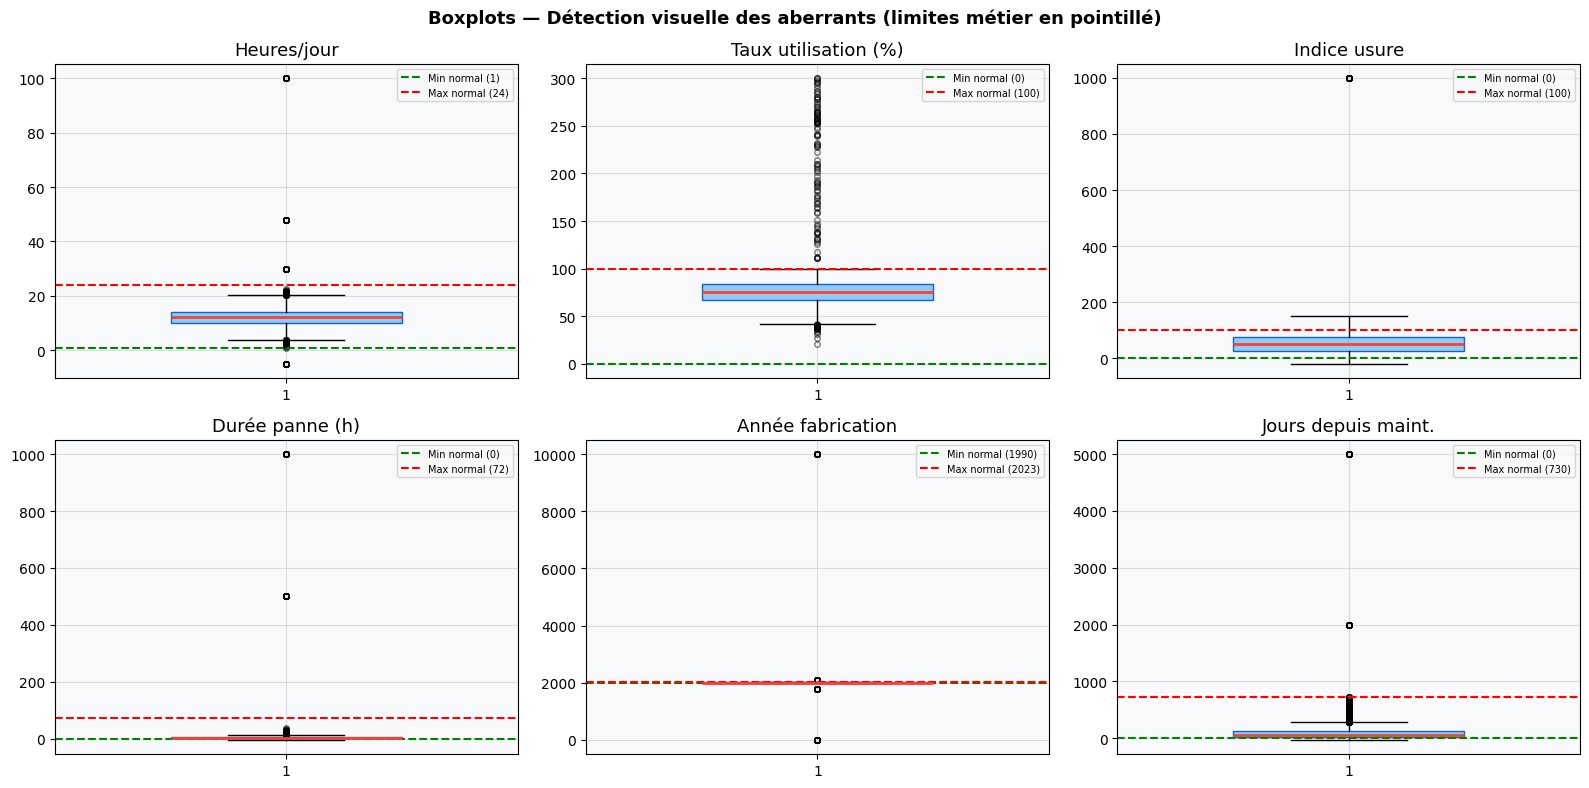

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

num_cols_ab = ['heures_par_jour','taux_utilisation_pct','indice_usure',
               'duree_moyenne_panne_h','annee_fabrication','jours_depuis_maintenance']
labels_ab   = ['Heures/jour','Taux utilisation (%)','Indice usure',
               'Durée panne (h)','Année fabrication','Jours depuis maint.']
expected    = [(1,24),(0,100),(0,100),(0,72),(1990,2023),(0,730)]

for i, (col, lbl, (lo, hi)) in enumerate(zip(num_cols_ab, labels_ab, expected)):
    data = df[col].dropna()
    bp   = axes[i].boxplot(data, vert=True, patch_artist=True, widths=0.5,
                            boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                            medianprops=dict(color='#F44336', linewidth=2),
                            flierprops=dict(marker='o', color='#FF5722', alpha=0.5, markersize=4))
    axes[i].axhline(lo, color='green', ls='--', lw=1.5, label=f'Min normal ({lo})')
    axes[i].axhline(hi, color='red',   ls='--', lw=1.5, label=f'Max normal ({hi})')
    axes[i].set_title(lbl)
    axes[i].legend(fontsize=7)

plt.suptitle("Boxplots — Détection visuelle des aberrants (limites métier en pointillé)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Distribution des variables numériques

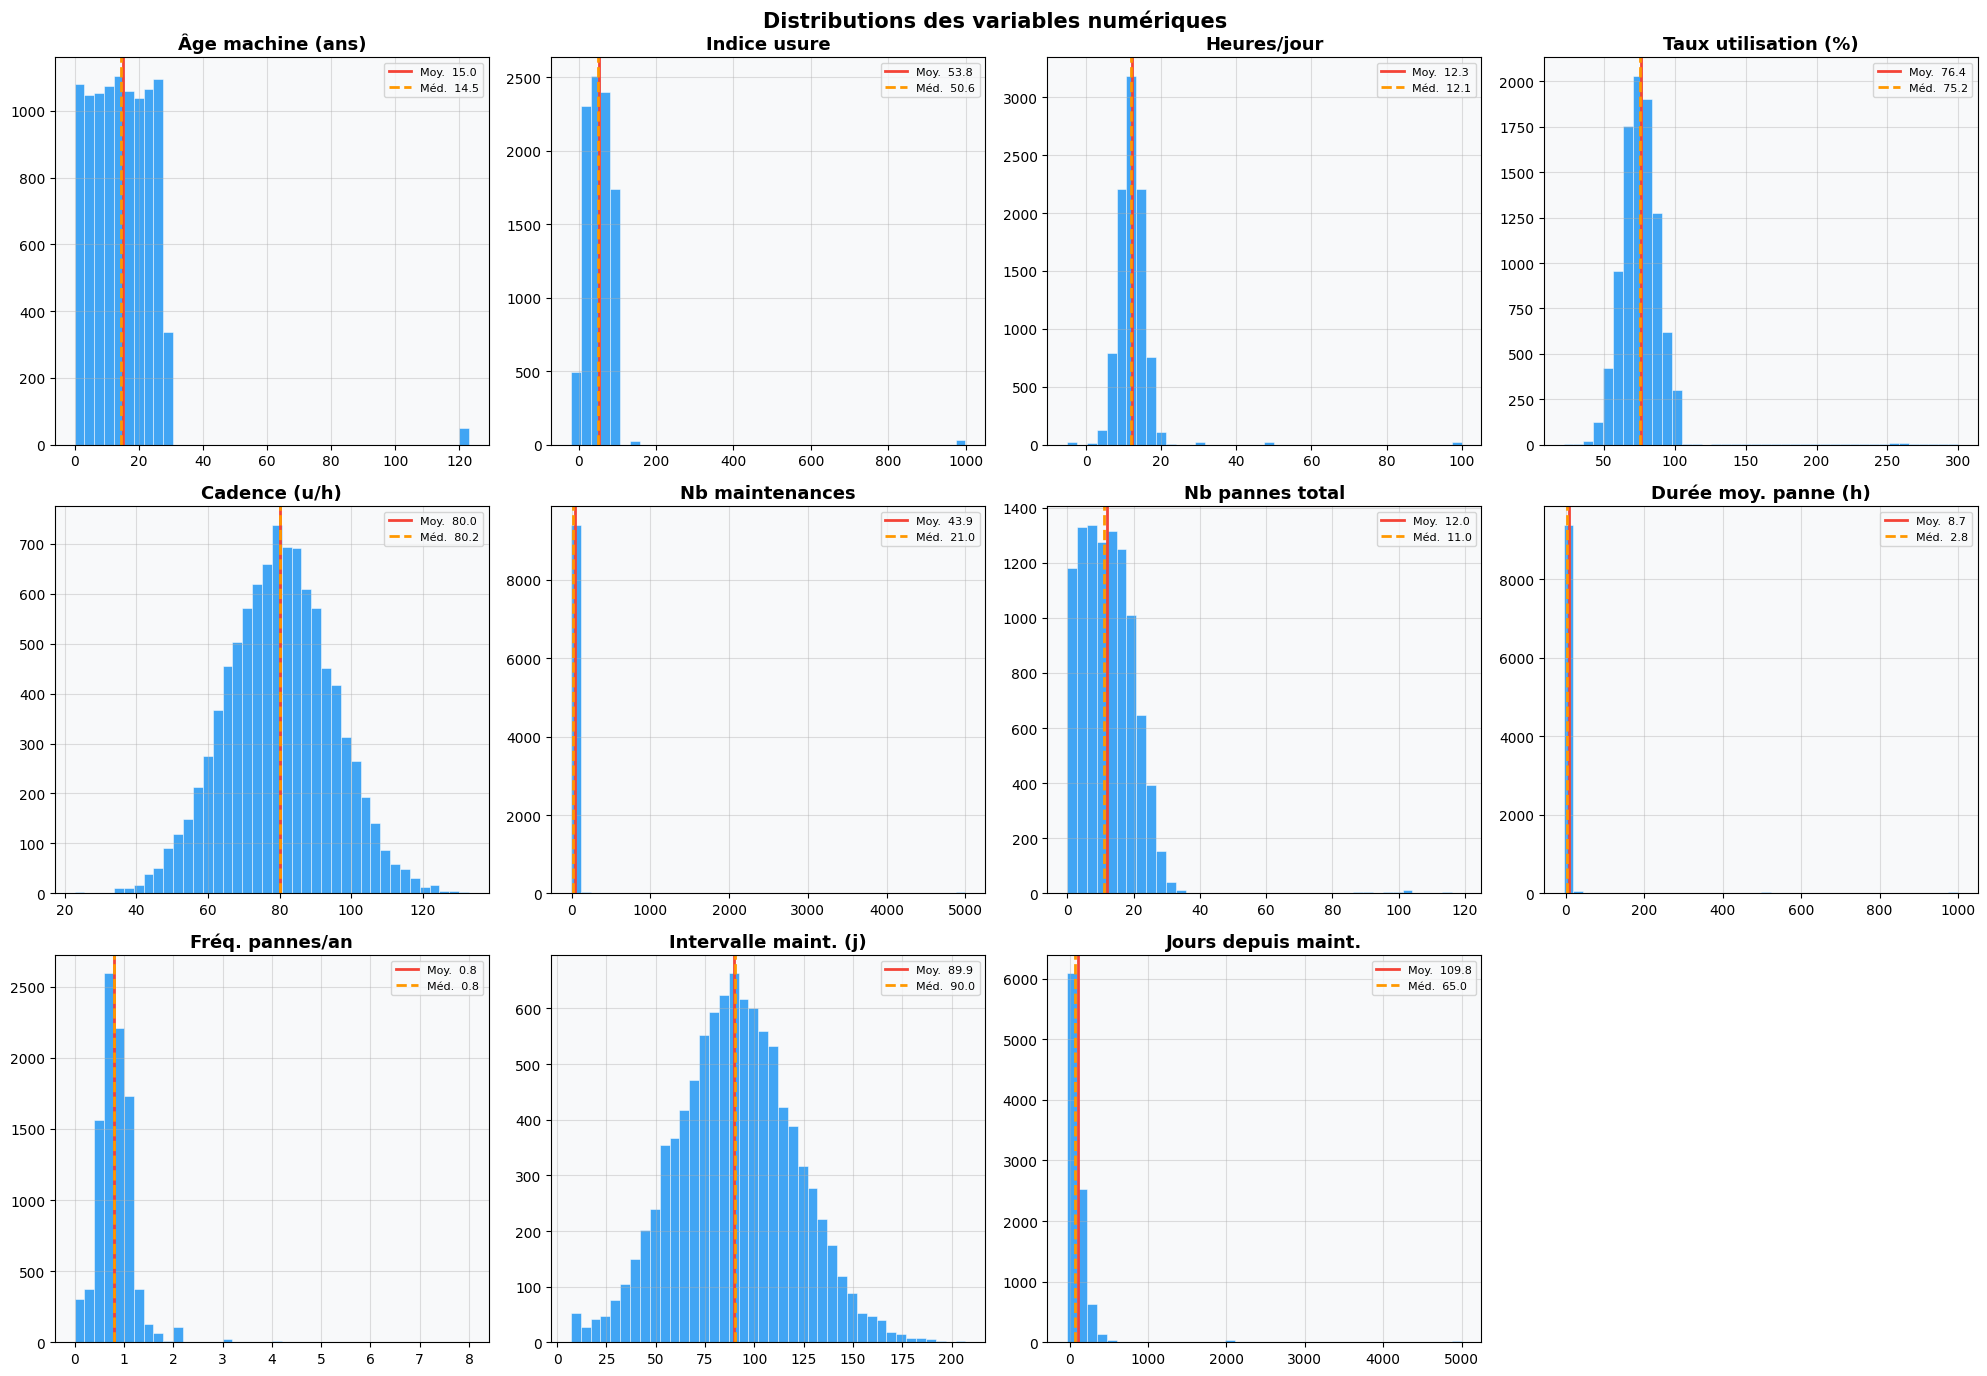

In [8]:
num_cols = ['age_machine_ans','indice_usure','heures_par_jour',
            'taux_utilisation_pct','cadence_moyenne_unit_h','nombre_maintenances',
            'nombre_total_pannes','duree_moyenne_panne_h','frequence_pannes_par_an',
            'intervalle_entre_maintenances_j','jours_depuis_maintenance']

labels = ['Âge machine (ans)','Indice usure','Heures/jour','Taux utilisation (%)',
          'Cadence (u/h)','Nb maintenances','Nb pannes total','Durée moy. panne (h)',
          'Fréq. pannes/an','Intervalle maint. (j)','Jours depuis maint.']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(num_cols, labels)):
    data = df[col].dropna()
    n, bins, patches = axes[i].hist(data, bins=40, color=C_OK, edgecolor='white',
                                     linewidth=0.4, alpha=0.85)
    axes[i].axvline(data.mean(),   color='#F44336', lw=2, ls='-',  label=f'Moy.  {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#FF9800', lw=2, ls='--', label=f'Méd.  {data.median():.1f}')
    axes[i].set_title(lbl, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("")

# Cacher la dernière case vide
axes[-1].set_visible(False)
plt.suptitle("Distributions des variables numériques", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Variables catégorielles

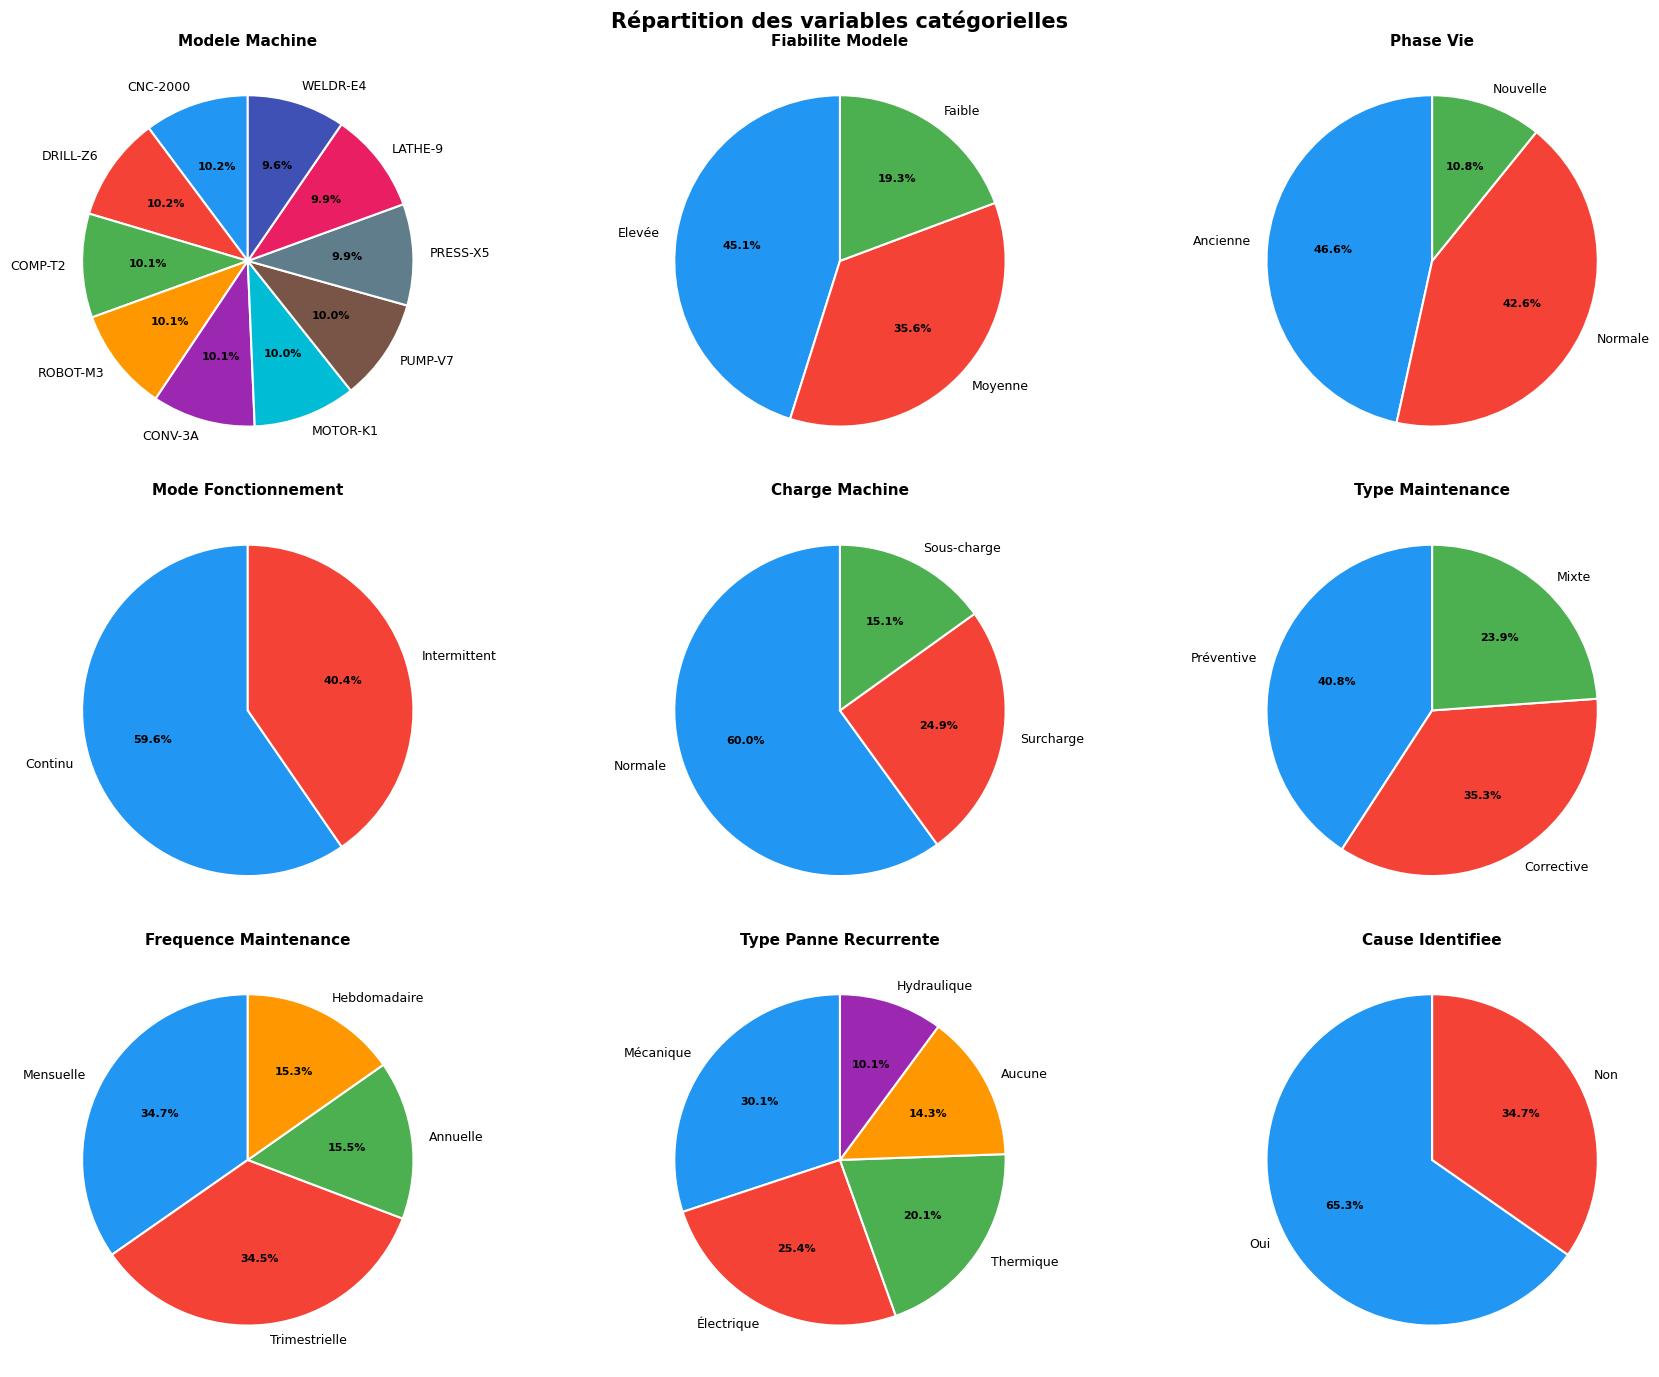

In [9]:
cat_cols = ['modele_machine','fiabilite_modele','phase_vie','mode_fonctionnement',
           'charge_machine','type_maintenance','frequence_maintenance',
           'type_panne_recurrente','cause_identifiee']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    colors = PALETTE[:len(vc)]
    wedges, texts, autotexts = axes[i].pie(
        vc.values, labels=vc.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        textprops={'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold', fontsize=11)

plt.suptitle("Répartition des variables catégorielles", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Analyse de la variable cible `panne`

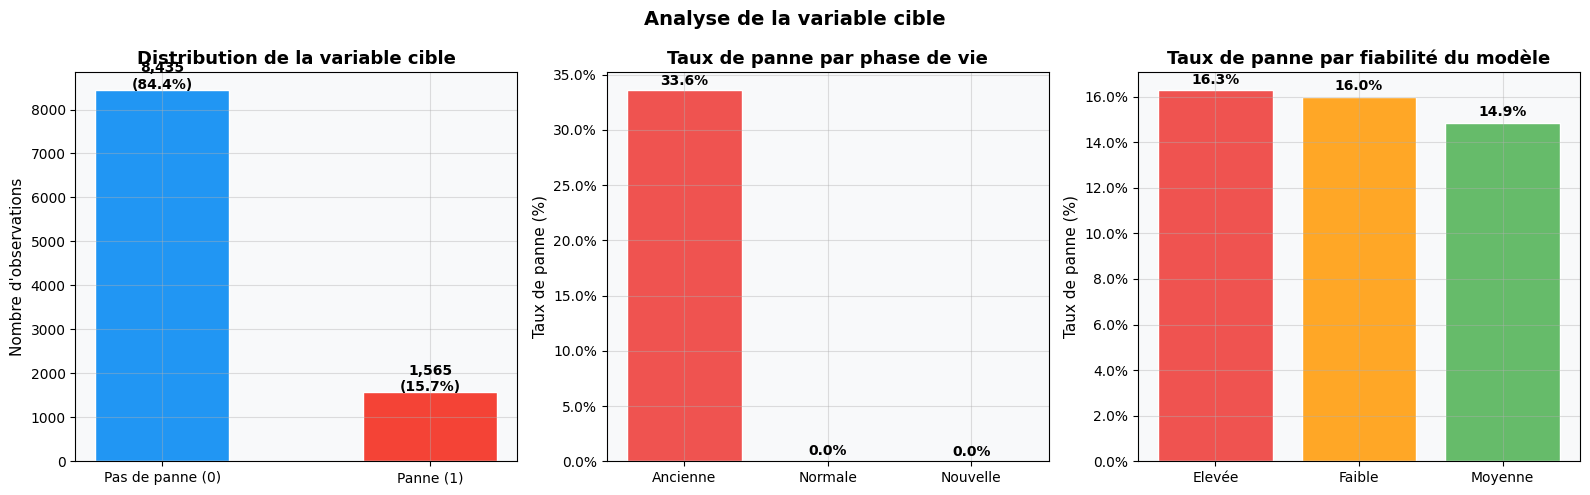


📊 Ratio déséquilibre : 5.4:1  →  Penser à SMOTE ou class_weight='balanced'


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
vc      = df['panne'].value_counts()
labels_ = ['Pas de panne (0)', 'Panne (1)']
colors_ = [C_OK, C_PANNE]
bars    = axes[0].bar(labels_, vc.values, color=colors_, edgecolor='white', width=0.5)
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+40,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title("Distribution de la variable cible", fontweight='bold')
axes[0].set_ylabel("Nombre d'observations")

# Panne par phase de vie
cross_phase = df.groupby('phase_vie')['panne'].mean().sort_values(ascending=False) * 100
colors_phase = ['#EF5350' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
                for v in cross_phase.values]
axes[1].bar(cross_phase.index, cross_phase.values, color=colors_phase, edgecolor='white')
axes[1].set_title("Taux de panne par phase de vie", fontweight='bold')
axes[1].set_ylabel("Taux de panne (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(cross_phase.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Panne par fiabilité modèle
cross_fid = df.groupby('fiabilite_modele')['panne'].mean().sort_values(ascending=False) * 100
axes[2].bar(cross_fid.index, cross_fid.values,
            color=['#EF5350','#FFA726','#66BB6A'][:len(cross_fid)], edgecolor='white')
axes[2].set_title("Taux de panne par fiabilité du modèle", fontweight='bold')
axes[2].set_ylabel("Taux de panne (%)")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(cross_fid.values):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle("Analyse de la variable cible", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Ratio déséquilibre : {vc[0]/vc[1]:.1f}:1  →  Penser à SMOTE ou class_weight='balanced'")


## 6. Corrélations & relations entre variables

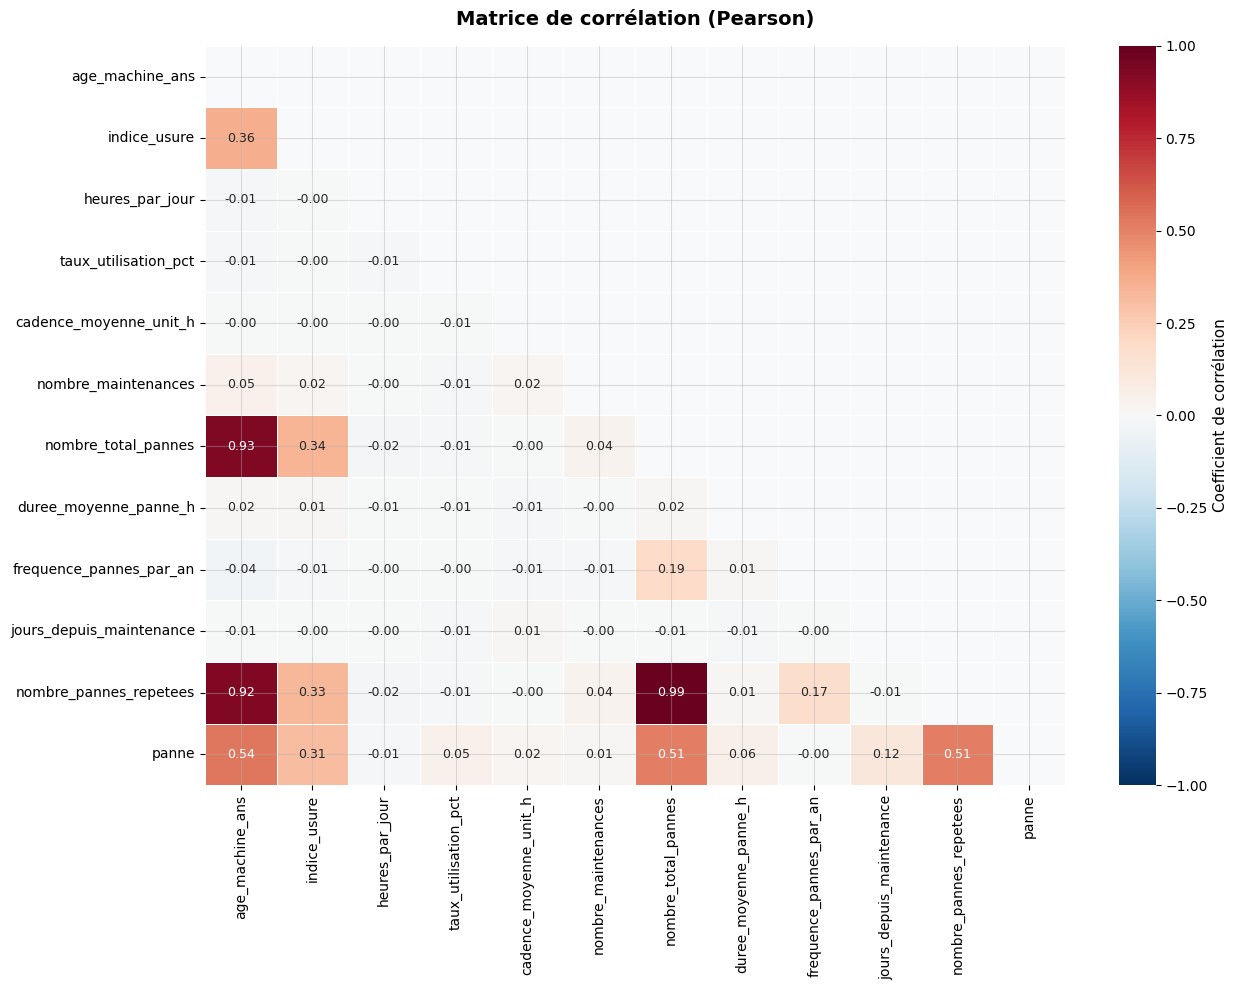


🔗 Top corrélations avec la variable cible 'panne' :
  age_machine_ans                     +0.539  ██████████
  nombre_total_pannes                 +0.511  ██████████
  nombre_pannes_repetees              +0.510  ██████████
  indice_usure                        +0.309  ██████
  jours_depuis_maintenance            +0.115  ██
  duree_moyenne_panne_h               +0.058  █
  taux_utilisation_pct                +0.055  █
  cadence_moyenne_unit_h              +0.020  
  heures_par_jour                     -0.013  
  nombre_maintenances                 +0.012  
  frequence_pannes_par_an             -0.003  


In [11]:
num_for_corr = ['age_machine_ans','indice_usure','heures_par_jour','taux_utilisation_pct',
                'cadence_moyenne_unit_h','nombre_maintenances','nombre_total_pannes',
                'duree_moyenne_panne_h','frequence_pannes_par_an','jours_depuis_maintenance',
                'nombre_pannes_repetees','panne']

corr = df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9},
            cbar_kws={'label': 'Coefficient de corrélation'})
ax.set_title("Matrice de corrélation (Pearson)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top corrélations avec panne
print("\n🔗 Top corrélations avec la variable cible 'panne' :")
top_corr = corr['panne'].drop('panne').abs().sort_values(ascending=False)
for col, val in top_corr.items():
    barre = '█' * int(val * 20)
    sign  = '+' if corr['panne'][col] > 0 else '-'
    print(f"  {col:<35} {sign}{val:.3f}  {barre}")


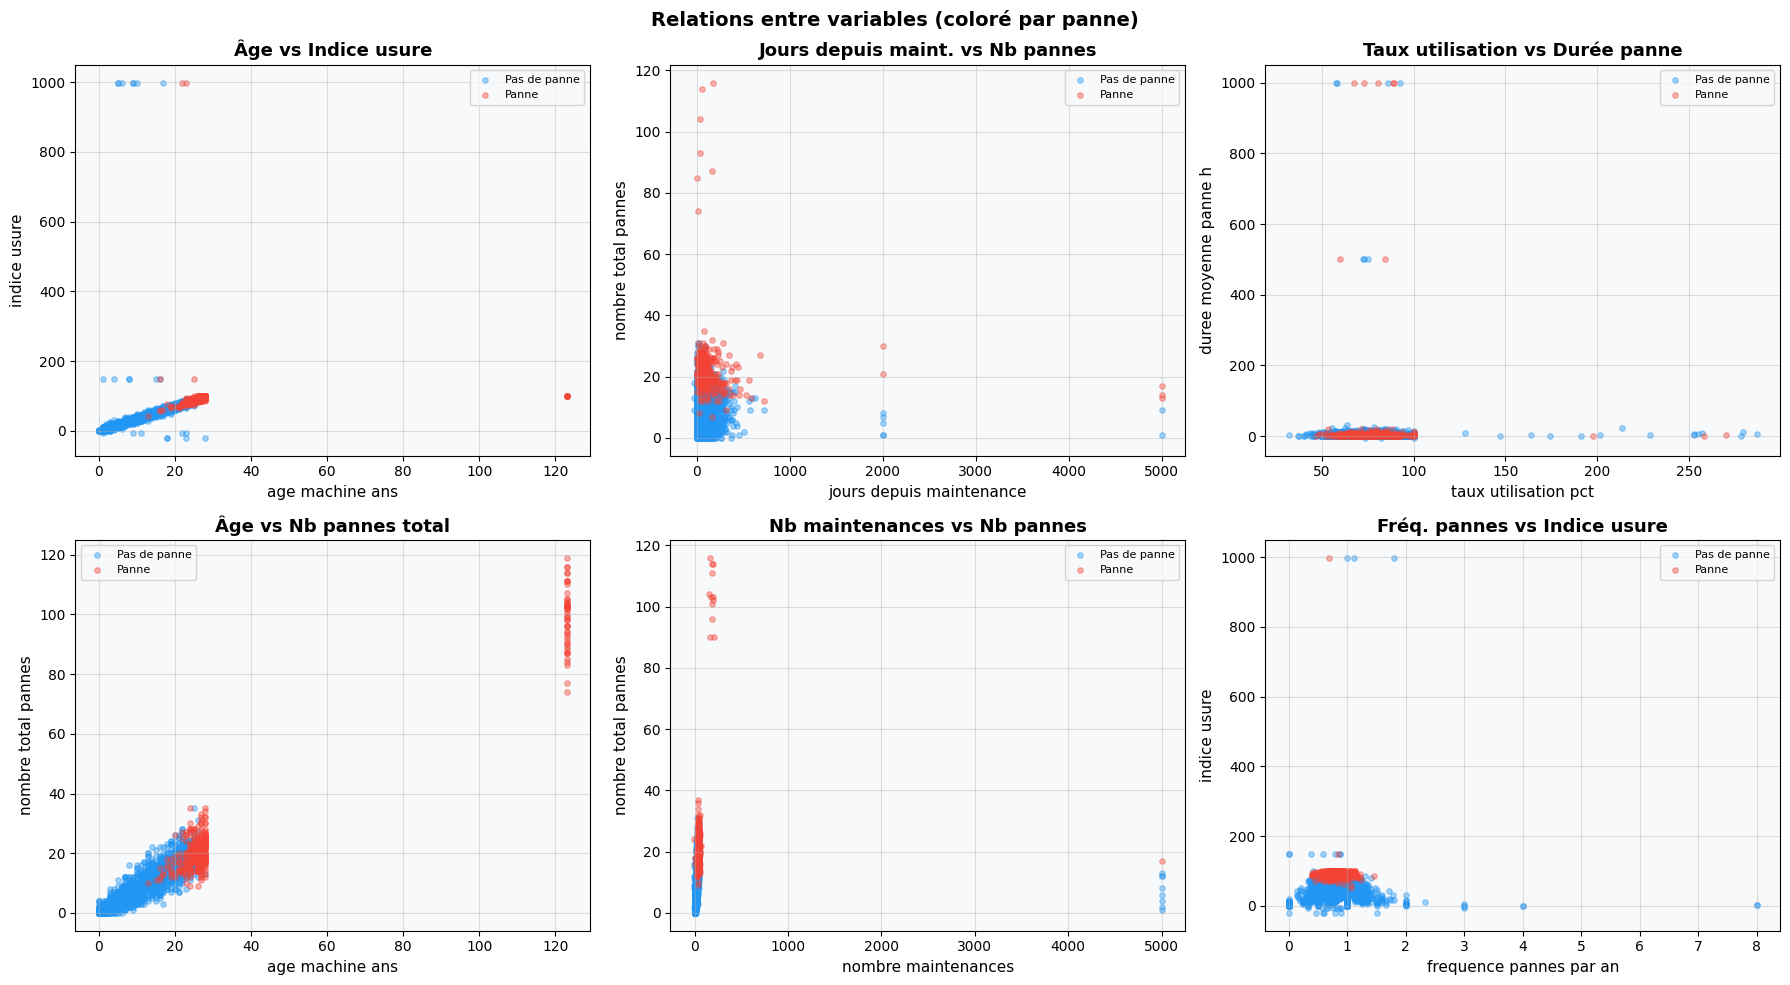

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pairs = [
    ('age_machine_ans',       'indice_usure',          'Âge vs Indice usure'),
    ('jours_depuis_maintenance','nombre_total_pannes',  'Jours depuis maint. vs Nb pannes'),
    ('taux_utilisation_pct',  'duree_moyenne_panne_h', 'Taux utilisation vs Durée panne'),
    ('age_machine_ans',       'nombre_total_pannes',   'Âge vs Nb pannes total'),
    ('nombre_maintenances',   'nombre_total_pannes',   'Nb maintenances vs Nb pannes'),
    ('frequence_pannes_par_an','indice_usure',          'Fréq. pannes vs Indice usure'),
]

for i, (x, y, title) in enumerate(pairs):
    data = df[[x, y, 'panne']].dropna().sample(min(2000, len(df)), random_state=42)
    for pval, color, label in [(0, C_OK, 'Pas de panne'), (1, C_PANNE, 'Panne')]:
        sub = data[data['panne']==pval]
        axes[i].scatter(sub[x], sub[y], c=color, alpha=0.4, s=15, label=label)
    axes[i].set_xlabel(x.replace('_',' '))
    axes[i].set_ylabel(y.replace('_',' '))
    axes[i].set_title(title, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle("Relations entre variables (coloré par panne)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Profil des machines — Panne vs Sans panne

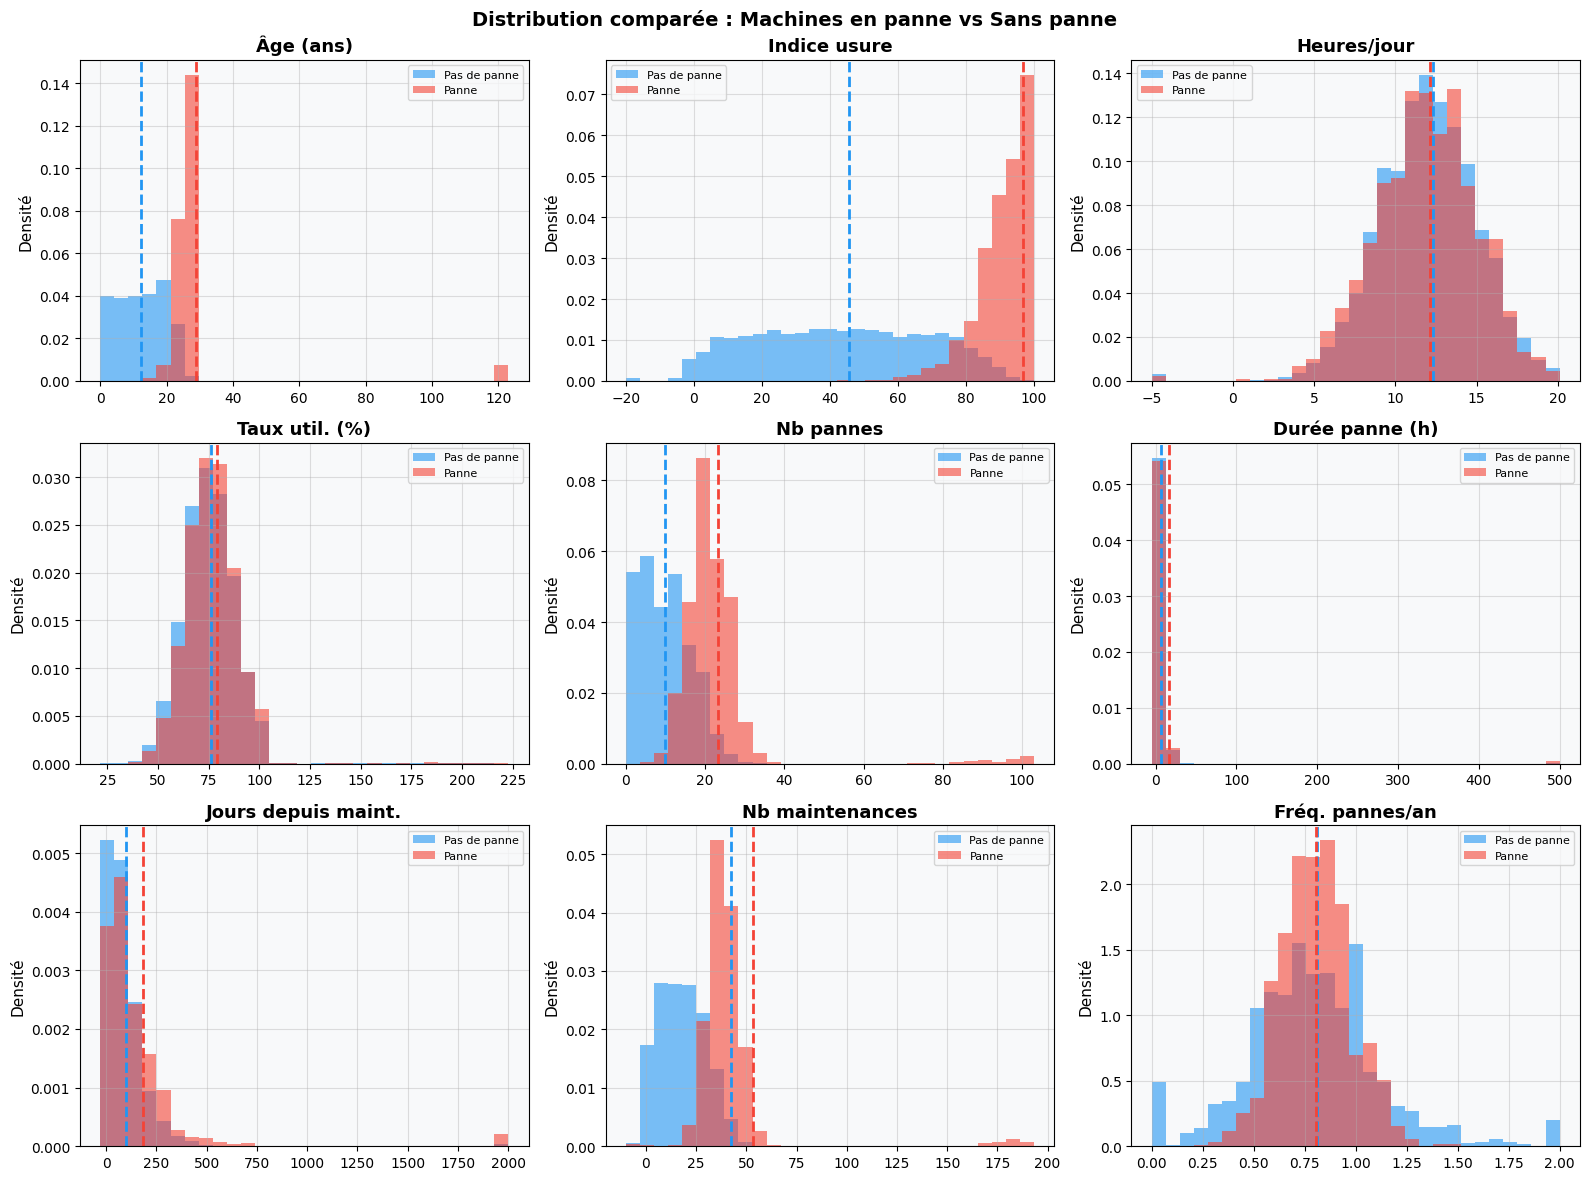

In [13]:
num_profile = ['age_machine_ans','indice_usure','heures_par_jour','taux_utilisation_pct',
               'nombre_total_pannes','duree_moyenne_panne_h','jours_depuis_maintenance',
               'nombre_maintenances','frequence_pannes_par_an']

labels_p = ['Âge (ans)','Indice usure','Heures/jour','Taux util. (%)','Nb pannes',
            'Durée panne (h)','Jours depuis maint.','Nb maintenances','Fréq. pannes/an']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(num_profile, labels_p)):
    d0 = df[df['panne']==0][col].dropna()
    d1 = df[df['panne']==1][col].dropna()
    bins_ = np.linspace(min(d0.min(), d1.min()), max(d0.quantile(0.99), d1.quantile(0.99)), 30)
    axes[i].hist(d0, bins=bins_, color=C_OK,    alpha=0.6, label='Pas de panne', density=True)
    axes[i].hist(d1, bins=bins_, color=C_PANNE, alpha=0.6, label='Panne',        density=True)
    axes[i].axvline(d0.mean(), color=C_OK,    lw=2, ls='--')
    axes[i].axvline(d1.mean(), color=C_PANNE, lw=2, ls='--')
    axes[i].set_title(lbl, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Densité")

plt.suptitle("Distribution comparée : Machines en panne vs Sans panne", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# Tableau de comparaison des moyennes
profile_df = df.groupby('panne')[num_profile].mean().T
profile_df.columns = ['Sans panne (0)', 'En panne (1)']
profile_df['Différence %'] = ((profile_df['En panne (1)'] - profile_df['Sans panne (0)'])
                               / profile_df['Sans panne (0)'] * 100).round(1)
profile_df.index = labels_p
profile_df.round(2).style\
    .background_gradient(subset=['Différence %'], cmap='RdYlGn_r')\
    .format({'Sans panne (0)': '{:.2f}', 'En panne (1)': '{:.2f}', 'Différence %': '{:+.1f}%'})


,Sans panne (0),En panne (1),Différence %
Âge (ans),12.43,28.93,+132.8%
Indice usure,45.76,96.67,+111.3%
Heures/jour,12.31,12.11,-1.6%
Taux util. (%),75.97,78.86,+3.8%
Nb pannes,9.90,23.30,+135.4%
Durée panne (h),7.09,17.07,+140.8%
Jours depuis maint.,96.08,183.74,+91.2%
Nb maintenances,42.14,53.17,+26.2%
Fréq. pannes/an,0.81,0.81,-0.4%


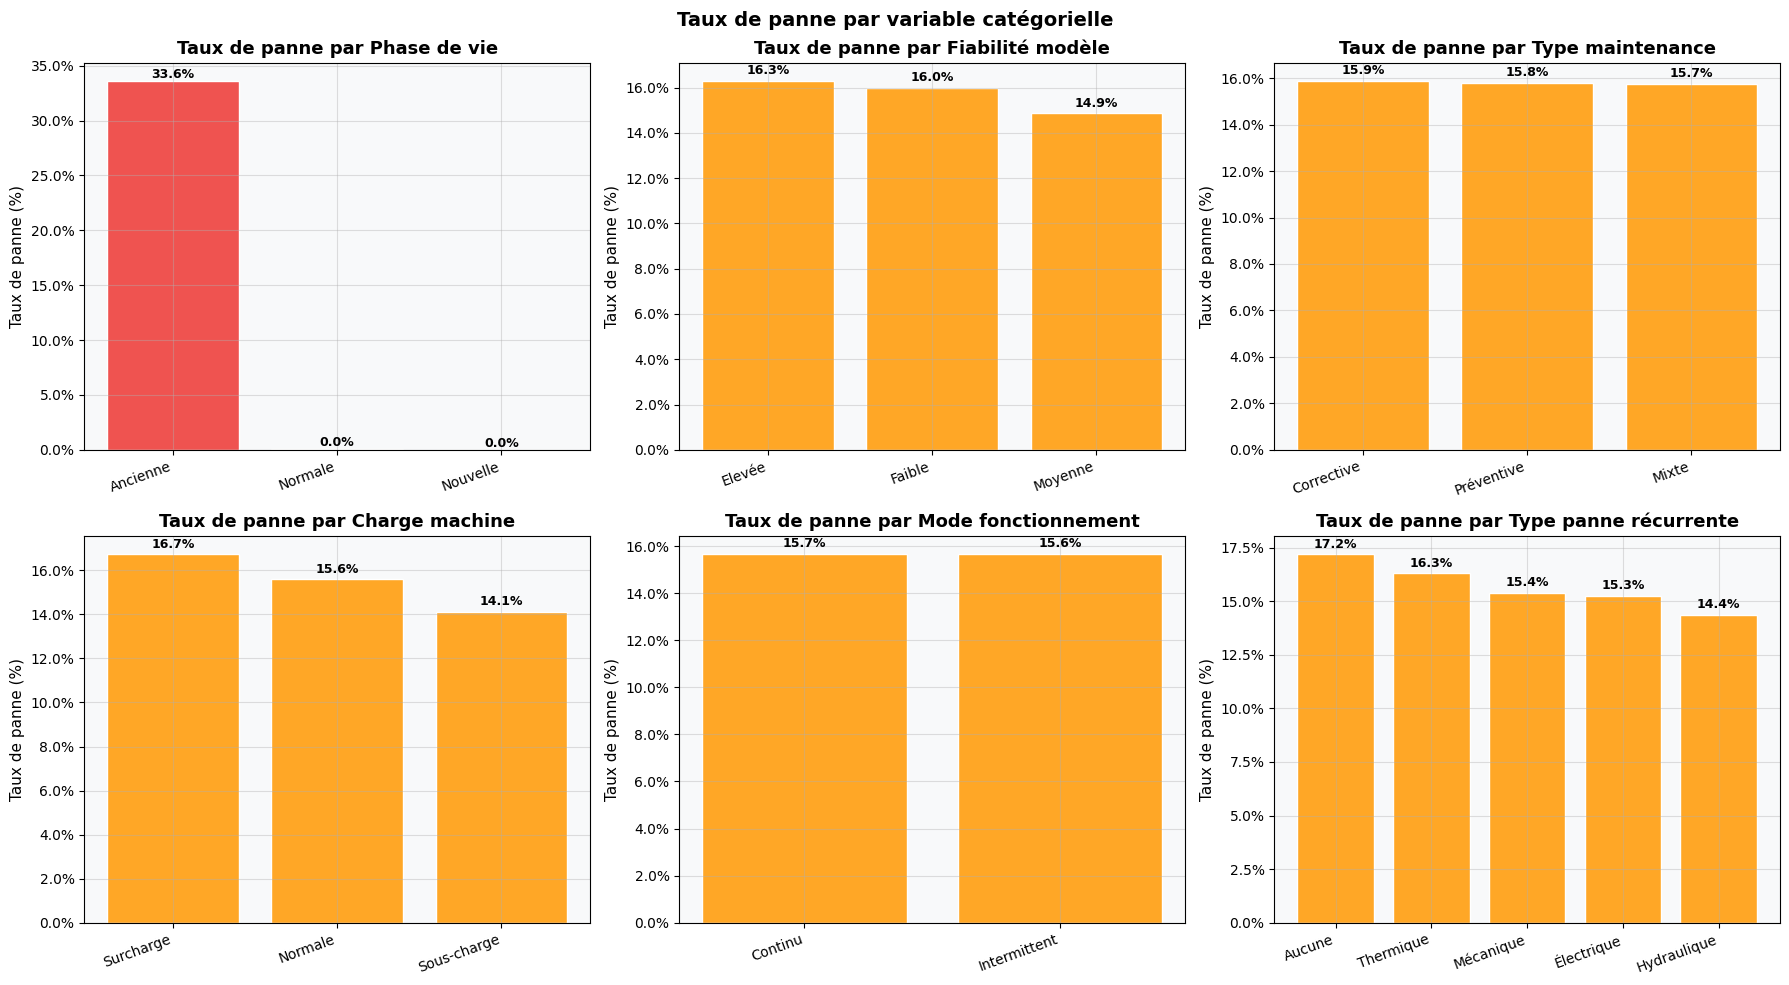

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_vs_target = ['phase_vie','fiabilite_modele','type_maintenance',
                 'charge_machine','mode_fonctionnement','type_panne_recurrente']
labels_cat    = ['Phase de vie','Fiabilité modèle','Type maintenance',
                 'Charge machine','Mode fonctionnement','Type panne récurrente']

for i, (col, lbl) in enumerate(zip(cat_vs_target, labels_cat)):
    cross = df.groupby(col)['panne'].mean().sort_values(ascending=False) * 100
    colors_ = ['#EF5350' if v>20 else '#FFA726' if v>12 else '#66BB6A' for v in cross.values]
    bars = axes[i].bar(cross.index, cross.values, color=colors_, edgecolor='white')
    axes[i].set_title(f"Taux de panne par {lbl}", fontweight='bold')
    axes[i].set_ylabel("Taux de panne (%)")
    axes[i].set_xticklabels(cross.index, rotation=20, ha='right')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for b, v in zip(bars, cross.values):
        axes[i].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Taux de panne par variable catégorielle", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Synthèse & Recommandations pré-modélisation

In [16]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE DE L'ANALYSE EXPLORATOIRE (EDA)                   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📐 DONNÉES                                                          ║
║  • 10 000 lignes × 28 colonnes (num + cat)                          ║
║  • Variable cible : panne (binaire 0/1)                              ║
║  • Déséquilibre : ~84% sans panne / ~16% panne                      ║
║                                                                      ║
║  ⚠️  QUALITÉ                                                         ║
║  • ~2.5% NaN distribués sur 14 colonnes → Imputation requise        ║
║  • ~8% aberrants (règles métier) → Traitement obligatoire           ║
║    Ex : heures > 24, taux > 100%, indice < 0...                     ║
║                                                                      ║
║  🔍 INSIGHTS CLÉS                                                    ║
║  • Age machine + indice d'usure = top prédicteurs de panne          ║
║  • Machines "Anciennes" ont un taux de panne nettement supérieur    ║
║  • Fiabilité "Faible" → taux de panne élevé (logique)               ║
║  • Maintenance "Corrective" associée à plus de pannes               ║
║  • Taux utilisation élevé corrèle avec les pannes                   ║
║                                                                      ║
║  🛠️  PRÉ-TRAITEMENT RECOMMANDÉ                                       ║
║  1. Corriger/supprimer les aberrants identifiés                      ║
║  2. Imputer les NaN (médiane pour num, mode pour cat)               ║
║  3. Encoder les variables catégorielles (OneHot / Label)            ║
║  4. Normaliser les variables numériques (StandardScaler)            ║
║  5. Gérer le déséquilibre : SMOTE ou class_weight='balanced'        ║
║                                                                      ║
║  🤖 MODÈLES À TESTER                                                 ║
║  • Baseline      : Régression Logistique                             ║
║  • Arbre         : Decision Tree / Random Forest                     ║
║  • Gradient Boost: XGBoost / LightGBM (recommandé)                  ║
║  • Évaluation    : F1-score, Recall (minimiser faux négatifs !)     ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE DE L'ANALYSE EXPLORATOIRE (EDA)                   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📐 DONNÉES                                                          ║
║  • 10 000 lignes × 28 colonnes (num + cat)                          ║
║  • Variable cible : panne (binaire 0/1)                              ║
║  • Déséquilibre : ~84% sans panne / ~16% panne                      ║
║                                                                      ║
║  ⚠️  QUALITÉ                                                         ║
║  • ~2.5% NaN distribués sur 14 colonnes → Imputation requise        ║
║  • ~8% aberrants (règles métier) → Traitement obligatoire           ║
║    Ex : heures > 24, taux > 100%, indice < 0...                     ║
║                                                         

### Bonus : Importance des variables (Random Forest rapide)

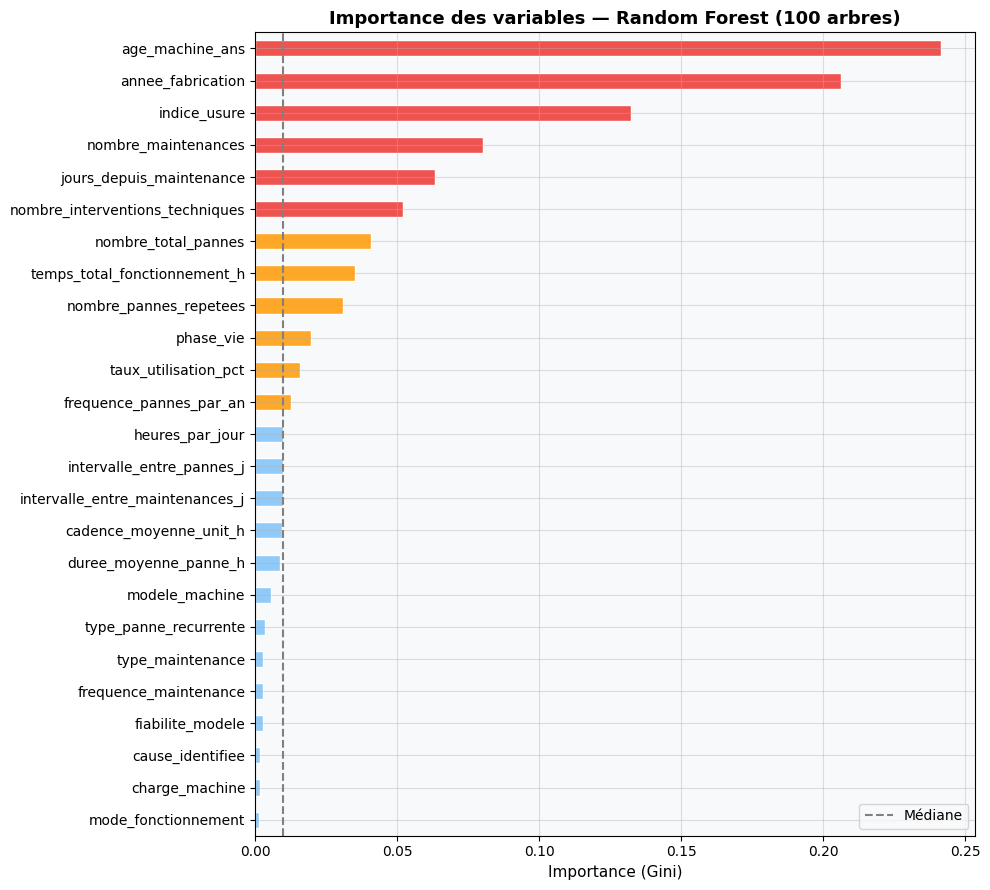


🏆 Top 5 variables les plus importantes :
  1. age_machine_ans                          0.2414
  2. annee_fabrication                        0.2061
  3. indice_usure                             0.1321
  4. nombre_maintenances                      0.0801
  5. jours_depuis_maintenance                 0.0632


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Préparation rapide
df_rf = df.copy()
cat_c = df_rf.select_dtypes('object').columns
for c in cat_c:
    df_rf[c] = LabelEncoder().fit_transform(df_rf[c].astype(str))

X = df_rf.drop(columns=['id','panne','date_derniere_maintenance'])
y = df_rf['panne']

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_imp, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors_ = ['#EF5350' if v > feat_imp.quantile(0.75) else
           '#FFA726' if v > feat_imp.median() else '#90CAF9'
           for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_, edgecolor='white')
ax.set_title("Importance des variables — Random Forest (100 arbres)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
ax.axvline(feat_imp.median(), color='gray', ls='--', lw=1.5, label='Médiane')
ax.legend()
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 variables les plus importantes :")
for i, (col, val) in enumerate(feat_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {col:<40} {val:.4f}")


---
## 9. Preparation des donnees pour la modelisation

Avant d'appliquer un algorithme de Machine Learning comme le SVM, il est indispensable de **preparer les donnees** :

1. **Imputation** des valeurs manquantes (mediane pour les variables numeriques, mode pour les categorielles).
2. **Encodage** des variables categorielles en variables numeriques (One-Hot Encoding).
3. **Standardisation** (centrage-reduction) : le SVM et l'ACP sont sensibles a l'echelle des variables. Sans standardisation, une variable comme `temps_total_fonctionnement_h` (valeurs en dizaines de milliers) dominerait completement une variable comme `frequence_pannes_par_an` (valeurs < 2).
4. **Separation** du jeu de donnees en ensemble d'entrainement (80%) et de test (20%).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Separation X / y
y = df['panne']
X = df.drop(columns=['id', 'panne', 'date_derniere_maintenance'])

num_cols_ml = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_ml = X.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numeriques : {len(num_cols_ml)}")
print(f"Variables categorielles : {len(cat_cols_ml)}")
print(f"Total features avant encodage : {len(num_cols_ml) + len(cat_cols_ml)}")


In [ ]:
# Pipeline de preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_ml),
        ('cat', categorical_transformer, cat_cols_ml)
    ])

# Separation train / test (80-20, stratifie)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Application du preprocessing
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

print(f"Dimensions apres encodage + standardisation :")
print(f"  X_train : {X_train_scaled.shape}")
print(f"  X_test  : {X_test_scaled.shape}")
print(f"  --> {X_train_scaled.shape[1]} colonnes au total (numeriques + one-hot)")


## 10. Analyse en Composantes Principales (A.C.P.)

Conformement a la theorie mathematique, l'**A.C.P.** permet d'analyser des donnees multidimensionnelles 
composees de plusieurs **variables quantitatives correlees**, et de les reduire en un nombre reduit de 
**nouvelles variables decorrelees** appelees "composantes principales", tout en conservant le maximum 
d'information (variance).

### Processus theorique applique :
1. **Donnees centrees-reduites** : Pour annuler l'effet des unites, toutes les variables sont standardisees (moyenne = 0, ecart-type = 1).
2. **Inertie totale** : Elle mesure la dispersion globale du nuage de points et correspond a la trace de la matrice de variances-covariances.
3. **Axes principaux** : Ce sont les vecteurs propres de la matrice de variances-covariances, ordonnes par valeur propre (variance) decroissante.
4. **Composantes principales** : Nouvelles variables (combinaisons lineaires) fournissant les coordonnees sur les axes principaux. Elles sont non-correlees.
5. **Critere global (Regle des 95%)** : On retient les premieres composantes dont la somme cumulee des variances represente au moins **95% de l'inertie totale**.

**Ajustement pratique :** 
Bien que l'ACP puisse traiter l'ensemble des variables, nous choisissons ici de l'appliquer uniquement sur les **7 variables les plus discriminantes** identifiees lors de l'EDA et via le Random Forest, afin de retirer le bruit inutile et d'obtenir un modele final tres precis et facile a utiliser en conditions reelles.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Preparation des donnees : on utilise SEULEMENT les colonnes discriminantes
SELECTED_FEATURES = ['age_machine_ans', 'indice_usure', 'nombre_total_pannes',
                     'nombre_pannes_repetees', 'nombre_maintenances', 'jours_depuis_maintenance', 
                     'phase_vie']
X_pca = df[SELECTED_FEATURES].copy()

# Identification des colonnes numeriques et categorielles
num_cols_pca = X_pca.select_dtypes(include=['int64', 'float64']).columns
cat_cols_pca = X_pca.select_dtypes(include=['object']).columns

# 2. Pipeline de pretraitement (Imputation + Standardisation/Encodage)
# Les donnees numeriques sont centrees-reduites (StandardScaler)
preprocessor_pca = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_pca),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_pca)
    ])

# 3. Application du pretraitement
X_pca_processed = preprocessor_pca.fit_transform(X_pca)

# Noms des colonnes apres encodage One-Hot
feature_names_pca = (num_cols_pca.tolist() + 
                     preprocessor_pca.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols_pca).tolist())

print(f"Dimensions avant ACP : {X_pca.shape[1]} variables -> {X_pca_processed.shape[1]} colonnes (apres encodage)")

# 4. Ajustement de l'ACP
pca = PCA(random_state=42)
pca.fit(X_pca_processed)

# 5. Calcul de la variance cumulee et regle des 95%
cumul_var = np.cumsum(pca.explained_variance_ratio_) * 100
n_components_95 = np.argmax(cumul_var >= 95) + 1

print(f"Nombre de composantes pour capturer 95% de l'inertie totale : {n_components_95}")

# Affichage du Scree Plot (Variance individuelle et cumulee)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
n_cols = len(pca.explained_variance_ratio_)
plt.bar(range(1, n_cols + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, color='blue')
plt.ylabel('Variance expliquee (%)')
plt.xlabel('Composante principale')
plt.title('Inertie par axe principal')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumul_var) + 1), cumul_var, marker='o', markersize=4, linestyle='-', color='red')
plt.axhline(y=95, color='k', linestyle='--', label='Seuil 95%')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} composantes')
plt.ylabel('Variance cumulee (%)')
plt.xlabel('Nombre de composantes')
plt.title('Inertie totale cumulee')
plt.legend()
plt.tight_layout()
plt.show()

# Affichage des poids (vecteurs propres) des variables sur la premiere composante
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=feature_names_pca
)
print("\nVariables contribuant le plus a l'axe 1 (PC1) :")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))


In [ ]:
# Graphique 1 : Scree Plot (variance expliquee cumulee)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Variance individuelle
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Variance Expliquee (%)')
axes[0].set_title('Variance expliquee par chaque composante', fontweight='bold')
axes[0].set_xlim(0.5, min(30, len(cumulative_var)) + 0.5)

# Variance cumulee
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var,
             'o-', color='#2196F3', markersize=4)
axes[1].axhline(y=95, color='#F44336', linestyle='--', linewidth=2, label='Seuil 95%')
axes[1].axvline(x=n_components_95, color='#4CAF50', linestyle='--', linewidth=2,
                label=f'{n_components_95} composantes')
axes[1].fill_between(range(1, n_components_95+1),
                     cumulative_var[:n_components_95], alpha=0.15, color='#4CAF50')
axes[1].set_xlabel('Nombre de Composantes')
axes[1].set_ylabel('Variance Cumulee (%)')
axes[1].set_title('Variance cumulee (Scree Plot)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0.5, min(30, len(cumulative_var)) + 0.5)
axes[1].set_ylim(0, 105)

plt.suptitle('Analyse en Composantes Principales : Choix du nombre de composantes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Application de l'ACP avec le nombre optimal de composantes
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Dimensions AVANT ACP : {X_train_scaled.shape[1]} colonnes")
print(f"Dimensions APRES ACP : {X_train_pca.shape[1]} composantes")
print(f"Reduction : {X_train_scaled.shape[1] - X_train_pca.shape[1]} colonnes supprimees")
print(f"Variance totale conservee : {pca.explained_variance_ratio_.sum()*100:.2f}%")


In [ ]:
# Graphique 2 : Projection 2D (PC1 vs PC2) coloree par panne
fig, ax = plt.subplots(figsize=(10, 7))

for pval, color, label in [(0, C_OK, 'Pas de panne'), (1, C_PANNE, 'Panne')]:
    mask = y_train.values == pval
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=color, alpha=0.4, s=12, label=label)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Projection ACP 2D : Machines en panne vs saines', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPC1 + PC2 capturent {(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1])*100:.1f}% de la variance totale.")
print("Si les couleurs se separent visuellement, cela signifie que l'ACP a capture")
print("des tendances discriminantes utiles pour le SVM.")


---
## 11. Application du SVM sur les composantes ACP

### Pourquoi le SVM (Support Vector Machine) ?

Le SVM est un algorithme de classification supervisee qui cherche l'**hyperplan optimal** separant les deux classes (panne / pas de panne). Avec un noyau **RBF** (Radial Basis Function), il peut capturer des frontieres de decision non lineaires.

### Avantages de combiner ACP + SVM :
- **Reduction du bruit** : l'ACP supprime les dimensions non informatives, ce qui aide le SVM.
- **Vitesse** : moins de features = entrainement plus rapide.
- **Meilleure generalisation** : reduire la dimensionnalite diminue le risque de sur-apprentissage.

### Gestion du desequilibre :
Comme notre dataset est desequilibre (~84% pas de panne, ~16% panne), nous utilisons `class_weight='balanced'` pour que le SVM penalise davantage les erreurs commises sur la classe minoritaire (les pannes).


In [ ]:
# Entrainement du SVM sur les composantes ACP
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_pca, y_train)
y_pred = svm_model.predict(X_test_pca)

# Metriques
acc = accuracy_score(y_test, y_pred)
print(f"Exactitude globale (Accuracy) : {acc:.4f} ({acc*100:.2f}%)")
print(f"\nRapport de classification detaille :\n")
print(classification_report(y_test, y_pred, target_names=['Pas de panne', 'Panne']))


In [ ]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Predit: Sain', 'Predit: Panne'],
            yticklabels=['Reel: Sain', 'Reel: Panne'])
ax.set_title('Matrice de Confusion : SVM sur composantes ACP', fontweight='bold', fontsize=13)
ax.set_ylabel('Valeur reelle')
ax.set_xlabel('Prediction du modele')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretation de la matrice de confusion :")
print(f"  Vrais Negatifs (TN)  : {tn} machines saines correctement identifiees")
print(f"  Faux Positifs (FP)   : {fp} fausses alertes (machine saine predite en panne)")
print(f"  Faux Negatifs (FN)   : {fn} pannes manquees (le plus dangereux !)")
print(f"  Vrais Positifs (TP)  : {tp} pannes correctement detectees")


### Interpretation des resultats

- **Recall (Rappel) de la classe Panne** : C'est la metrique la plus importante en maintenance predictive. Elle indique la proportion de pannes reelles que le modele a detectees. Un rappel eleve signifie que l'on rate tres peu de pannes.
- **Precision de la class Panne** : Parmi les machines que le modele predit "en panne", combien le sont reellement. Une precision faible signifie beaucoup de fausses alertes.
- **F1-Score** : Moyenne harmonique de la precision et du rappel, utile quand les classes sont desequilibrees.

En maintenance predictive, on prefere generalement **maximiser le rappel** (detecter un maximum de pannes) quitte a avoir quelques fausses alertes, plutot que de rater des pannes reelles.
